## Model pipelines

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE , VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
import pandas as pd
df_not_normalized = pd.read_csv("/content/drive/MyDrive/CMAPS_VAE/numerical_variables_mapping.csv")
df_normalized = pd.read_csv("/content/drive/MyDrive/CMAPS_VAE/numerical_variables_mapping_normalized.csv")
df_categorical = pd.read_csv("/content/drive/MyDrive/CMAPS_VAE/categorical_variables_mapping.csv")

##1) Feature selection previo



In [4]:
print(df_categorical.shape)
df_categorical.head(5)

(1191, 5)


,row_id,dname_drug1,dname_drug2,cell_line_name,disease_cui
0,0,5-Fluorouracil,Bortezomib,HT29,C0338106
1,1,5-Fluorouracil,Bortezomib,HT29,C0338106
2,2,5-Fluorouracil,Bortezomib,HT29,C0338106
3,3,5-Fluorouracil,Bortezomib,HT29,C0338106
4,4,5-Fluorouracil,Dasatinib,HT29,C0338106


In [5]:
print(df_not_normalized.shape)
df_not_normalized.head(5)

(1191, 41)


,latent_0_drug1,latent_1_drug1,latent_2_drug1,latent_3_drug1,latent_4_drug1,latent_0_drug2,latent_1_drug2,latent_2_drug2,latent_3_drug2,latent_4_drug2,...,sep_mean_dru1_dru2,sep_std_dru1_dru2,zscore_dru1_dru2,ratio_links_dis_dru1,ratio_links_dis_dru2,synergy_zip,synergy_loewe,synergy_hsa,synergy_bliss,row_id
0,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,2.112442,-1.463338,3.058471,2.248301,0
1,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,2.780004,0.134037,4.655846,3.845676,1
2,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,3.442829,0.657474,5.179283,4.369114,2
3,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,2.709433,-0.225963,4.295846,3.485676,3
4,0.038676,0.060642,-0.250747,0.069042,-0.053469,-0.071840,-0.000804,-0.086574,0.114252,0.126682,...,0.0,0.494699,5.922885,0.0,0.056534,-0.328969,5.718725,8.312947,-1.322924,4


In [6]:
print(df_normalized.shape)
df_normalized.head(5)

(1191, 41)


,latent_0_drug1,latent_1_drug1,latent_2_drug1,latent_3_drug1,latent_4_drug1,latent_0_drug2,latent_1_drug2,latent_2_drug2,latent_3_drug2,latent_4_drug2,...,sep_mean_dru1_dru2,sep_std_dru1_dru2,zscore_dru1_dru2,ratio_links_dis_dru1,ratio_links_dis_dru2,synergy_zip,synergy_loewe,synergy_hsa,synergy_bliss,row_id
0,-0.105534,0.264075,-0.328694,-0.294372,0.134275,0.618728,2.424600,2.870706,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,2.112442,-1.463338,3.058471,2.248301,0
1,-0.105534,0.264075,-0.328694,-0.294372,0.134275,0.618728,2.424600,2.870706,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,2.780004,0.134037,4.655846,3.845676,1
2,-0.105534,0.264075,-0.328694,-0.294372,0.134275,0.618728,2.424600,2.870706,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,3.442829,0.657474,5.179283,4.369114,2
3,-0.105534,0.264075,-0.328694,-0.294372,0.134275,0.618728,2.424600,2.870706,0.863541,-1.201727,...,0.0,0.494699,5.922885,0.0,0.051242,2.709433,-0.225963,4.295846,3.485676,3
4,-0.105534,0.264075,-0.328694,-0.294372,0.134275,-0.416104,-0.003761,-0.224275,0.114252,0.126682,...,0.0,0.494699,5.922885,0.0,0.056534,-0.328969,5.718725,8.312947,-1.322924,4


In [7]:
from sklearn.feature_selection import VarianceThreshold

# 1. Seleccionar solo las variables numéricas (sin row_id ni target)
features_only_raw = df_not_normalized.drop(columns=["row_id", "synergy_hsa"])

# 2. Calcular varianzas
variances = features_only_raw.var().sort_values()

# 3. Mostrar todas las varianzas ordenadas
print("📊 Varianzas de las variables (ordenadas):")
for feature, var in variances.items():
    print(f"{feature:<30} -> {var:.6f}")


📊 Varianzas de las variables (ordenadas):
ji_dis_drug2                   -> 0.000010
ji_dis_drug1                   -> 0.000010
ji_drug1_drug2                 -> 0.008660
ratio_links_dis_dru1           -> 0.009787
ratio_links_dis_dru2           -> 0.011598
sep_std_dru1_dru2              -> 0.013364
sep_mean_dru1_dru2             -> 0.013678
Dc_std_dis_dru2                -> 0.013854
Dc_std_dis_dru1                -> 0.014963
oc_drug1_drug2                 -> 0.027033
latent_3_drug1                 -> 0.028014
latent_4_drug1                 -> 0.044610
Dc_mean_dis_dru1               -> 0.087779
Dc_mean_dis_dru2               -> 0.096357
latent_4_drug2                 -> 0.112955
latent_3_drug2                 -> 0.125789
oc_dis_drug2                   -> 0.144090
obs_sep_dru1_dru2              -> 0.166634
oc_dis_drug1                   -> 0.170903
latent_0_drug1                 -> 0.205780
latent_0_drug2                 -> 0.237520
latent_1_drug1                 -> 0.250031
latent_1_dru

In [8]:
## we will use as a threshold 0.01
df_not_normalized = df_not_normalized.drop(columns=["ji_dis_drug2","ji_dis_drug1","ji_drug1_drug2","ratio_links_dis_dru1"])
df_normalized = df_normalized.drop(columns=["ji_dis_drug2","ji_dis_drug1","ji_drug1_drug2","ratio_links_dis_dru1"])

In [9]:
print(df_not_normalized.shape)
print(df_normalized.shape)
#4 columns removed

(1191, 37)
(1191, 37)


### 2) Model pipelines

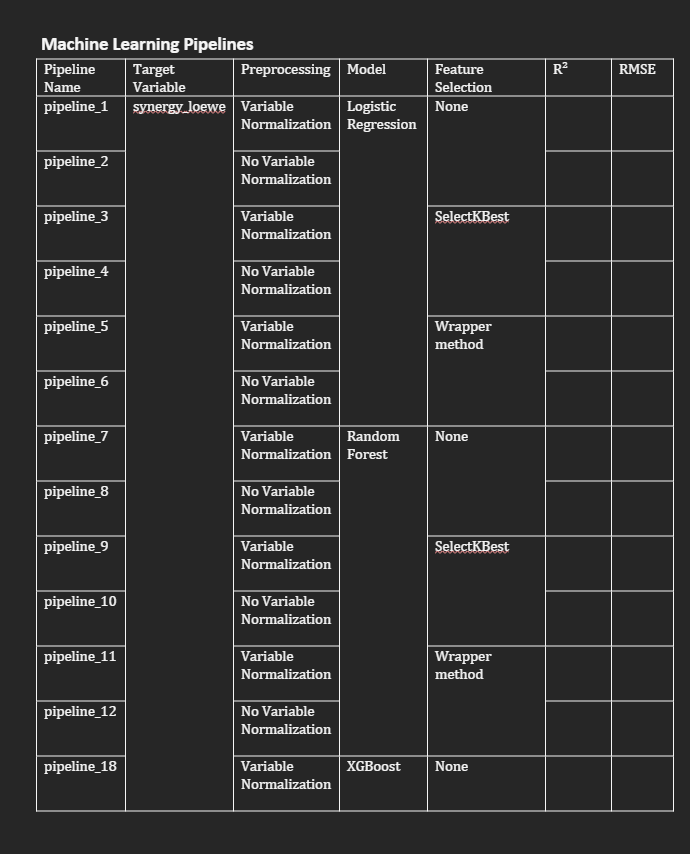

In [10]:
pipeline_configs = []

models = ['logreg', 'rf', 'xgb']
feature_selections = [None, 'selectkbest', 'wrapper']
preprocessings = ['normalized', 'raw']

# Construir las 18 configuraciones
for model_type in models:
    for fs in feature_selections:
        for prep in preprocessings:
            pipeline_configs.append({
                "model_type": model_type,
                "feature_selection": fs,
                "preprocessing": prep
            })


In [11]:
pipeline_configs

[{'model_type': 'logreg',
  'feature_selection': None,
  'preprocessing': 'normalized'},
 {'model_type': 'logreg', 'feature_selection': None, 'preprocessing': 'raw'},
 {'model_type': 'logreg',
  'feature_selection': 'selectkbest',
  'preprocessing': 'normalized'},
 {'model_type': 'logreg',
  'feature_selection': 'selectkbest',
  'preprocessing': 'raw'},
 {'model_type': 'logreg',
  'feature_selection': 'wrapper',
  'preprocessing': 'normalized'},
 {'model_type': 'logreg',
  'feature_selection': 'wrapper',
  'preprocessing': 'raw'},
 {'model_type': 'rf',
  'feature_selection': None,
  'preprocessing': 'normalized'},
 {'model_type': 'rf', 'feature_selection': None, 'preprocessing': 'raw'},
 {'model_type': 'rf',
  'feature_selection': 'selectkbest',
  'preprocessing': 'normalized'},
 {'model_type': 'rf',
  'feature_selection': 'selectkbest',
  'preprocessing': 'raw'},
 {'model_type': 'rf',
  'feature_selection': 'wrapper',
  'preprocessing': 'normalized'},
 {'model_type': 'rf', 'feature_se

## now lests prepare the train test split

In [12]:
# Diccionario de mapeo de disease_cui a nombre legible
cui_to_disease = {
    "C0338106": "Colon Adenocarcinoma",
    "C0600139": "Prostate Carcinoma",
    "C1134719": "Breast (Invasive Ductal)",
    "C0152013": "Lung Adenocarcinoma"
}

# Crear columna 'disease_name' a partir del mapping
df_categorical["disease_name"] = df_categorical["disease_cui"].map(cui_to_disease)

# Definir las enfermedades para cada conjunto
train_diseases = ["Colon Adenocarcinoma", "Breast (Invasive Ductal)", "Prostate Carcinoma"]
test_diseases = ["Lung Adenocarcinoma"]

# Obtener los row_id correspondientes
row_ids_train = df_categorical[df_categorical["disease_name"].isin(train_diseases)]["row_id"].tolist()
row_ids_test = df_categorical[df_categorical["disease_name"].isin(test_diseases)]["row_id"].tolist()

# (Opcional) Mostrar cuántos hay
print(f"Train: {len(row_ids_train)} rows | Test: {len(row_ids_test)} rows")

Train: 1102 rows | Test: 89 rows


In [13]:
X_raw = df_not_normalized.drop(columns=["synergy_loewe","synergy_zip","synergy_hsa","synergy_bliss"])
X_norm = df_normalized.drop(columns=["synergy_loewe","synergy_zip","synergy_hsa","synergy_bliss"])
y = df_not_normalized["synergy_hsa"]  # igual en ambos casos

In [14]:
X_raw

,latent_0_drug1,latent_1_drug1,latent_2_drug1,latent_3_drug1,latent_4_drug1,latent_0_drug2,latent_1_drug2,latent_2_drug2,latent_3_drug2,latent_4_drug2,...,Dc_mean_dis_dru2,Dc_std_dis_dru2,Dc_zscore_dis_dru2,min_spl_dru1_dru2,obs_sep_dru1_dru2,sep_mean_dru1_dru2,sep_std_dru1_dru2,zscore_dru1_dru2,ratio_links_dis_dru2,row_id
0,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,1.044333,0.176166,-0.251656,2.0,0.0,0.0,0.494699,5.922885,0.051242,0
1,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,1.044333,0.176166,-0.251656,2.0,0.0,0.0,0.494699,5.922885,0.051242,1
2,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,1.044333,0.176166,-0.251656,2.0,0.0,0.0,0.494699,5.922885,0.051242,2
3,0.038676,0.060642,-0.250747,0.069042,-0.053469,0.432284,1.410122,2.739043,0.863541,-1.201727,...,1.044333,0.176166,-0.251656,2.0,0.0,0.0,0.494699,5.922885,0.051242,3
4,0.038676,0.060642,-0.250747,0.069042,-0.053469,-0.071840,-0.000804,-0.086574,0.114252,0.126682,...,1.008900,0.093866,-0.094816,2.0,0.0,0.0,0.494699,5.922885,0.056534,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1186,-0.065987,0.087140,-0.112513,0.114887,0.061215,-0.016287,0.094303,-0.190999,0.136447,-0.083395,...,1.608000,0.514136,0.762444,2.0,0.0,0.0,0.495282,5.915228,0.000000,1186
1187,0.063310,0.133210,0.078170,0.084622,-0.055479,0.634798,-0.132449,2.454480,1.966487,0.556670,...,1.030333,0.182184,-0.166498,2.0,0.0,0.0,0.495282,5.915228,0.053768,1187
1188,0.003755,-0.098752,-0.011383,-0.303566,-0.162485,0.432284,1.410122,2.739043,0.863541,-1.201727,...,1.044333,0.176166,-0.251656,2.0,0.0,0.0,0.494699,5.922885,0.051242,1188
1189,0.040340,0.002213,-0.459703,0.049285,-0.094661,-0.016287,0.094303,-0.190999,0.136447,-0.083395,...,1.608000,0.514136,0.762444,2.0,0.0,0.0,0.495282,5.915228,0.000000,1189


In [16]:
# Crear los conjuntos de entrenamiento y prueba a partir del row_id y disease

# 1. Filtrar X e y desde df_raw
X_train_raw = X_raw[X_raw["row_id"].isin(row_ids_train)].drop(columns=["row_id"])
X_test_raw = X_raw[X_raw["row_id"].isin(row_ids_test)].drop(columns=["row_id"])

# 2. Filtrar X desde df_norm
X_train_norm = X_norm[X_norm["row_id"].isin(row_ids_train)].drop(columns=["row_id"])
X_test_norm = X_norm[X_norm["row_id"].isin(row_ids_test)].drop(columns=["row_id"])

# 3. y es la misma para ambas versiones (tomada desde df_raw)
y_train = df_not_normalized[df_not_normalized["row_id"].isin(row_ids_train)]["synergy_hsa"]
y_test = df_not_normalized[df_not_normalized["row_id"].isin(row_ids_test)]["synergy_hsa"]

# (Opcional) Verifica tamaños:
print("Train:", X_train_raw.shape, X_train_norm.shape, y_train.shape)
print("Test:", X_test_raw.shape, X_test_norm.shape, y_test.shape)


Train: (1102, 32) (1102, 32) (1102,)
Test: (89, 32) (89, 32) (89,)


In [17]:
feature_names = X_train_raw.columns.tolist()


In [18]:
from sklearn.linear_model import Ridge

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

results = []

def run_pipeline(index, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test, feature_names):
    config = pipeline_configs[index]

    model_type = config["model_type"]
    feature_selection = config["feature_selection"]
    preprocessing = config["preprocessing"]

    print(f"\n▶️ Ejecutando pipeline {index + 1} | Modelo: {model_type} | FS: {feature_selection} | Prep: {preprocessing}")

    # Selección del dataset según el preprocesamiento
    if preprocessing == "normalized":
        X_train, X_test = X_train_norm, X_test_norm
    elif preprocessing == "raw":
        X_train, X_test = X_train_raw, X_test_raw
    else:
        raise ValueError("Preprocessing debe ser 'normalized' o 'raw'.")

    # Selección del modelo y parámetros
    if model_type == "logreg":
        model = Ridge()
        param_grid = {"model__alpha": [0.01, 0.1, 1, 10]}
    elif model_type == "rf":
        model = RandomForestRegressor()
        param_grid = {"model__n_estimators": [50, 100], "model__max_depth": [5, 10]}
    elif model_type == "xgb":
        model = XGBRegressor()
        param_grid = {"model__n_estimators": [50, 100], "model__max_depth": [3, 6]}
    else:
        raise ValueError(f"Modelo no soportado: {model_type}")

    # Construir el pipeline
    steps = []
    if feature_selection == "selectkbest":
        steps.append(("feature_selection", SelectKBest(score_func=f_regression, k=10)))
    elif feature_selection == "wrapper":
        steps.append(("feature_selection", RFE(estimator=model, n_features_to_select=10)))
    steps.append(("model", model))

    pipeline = Pipeline(steps)

    # Grid Search con validación cruzada
    pipeline = GridSearchCV(pipeline, param_grid=param_grid, cv=5)
    pipeline.fit(X_train, y_train)
    best_model = pipeline.best_estimator_

    # Predicción y evaluación
    y_pred = best_model.predict(X_test)
    r2_cv = cross_val_score(best_model, X_train, y_train, cv=5, scoring="r2").mean()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)

    # Identificar las columnas seleccionadas (si hay selección de características)
    if feature_selection == "selectkbest":
        mask = best_model.named_steps["feature_selection"].get_support()
        selected_features = [name for name, keep in zip(feature_names, mask) if keep]
        print(f"📌 Características seleccionadas (SelectKBest): {selected_features}")
    elif feature_selection == "wrapper":
        mask = best_model.named_steps["feature_selection"].get_support()
        selected_features = [name for name, keep in zip(feature_names, mask) if keep]
        print(f"📌 Características seleccionadas (RFE): {selected_features}")
    else:
        selected_features = feature_names
        print(f"📌 Características usadas (sin selección): {selected_features}")

    # Guardar resultados
    results.append({
        "Pipeline": index + 1,
        "Model": model_type,
        "Feature Selection": feature_selection,
        "Preprocessing": preprocessing,
        "R2": round(r2, 4),
        "R2_CV": round(r2_cv, 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MedAE": round(medae, 4),
        "Selected Features": selected_features
    })

    print(f"✅ R2: {r2:.4f} | R2 CV (train): {r2_cv:.4f} | RMSE: {rmse:.4f}")




In [19]:
for i in range(10):
    run_pipeline(i, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 1 | Modelo: logreg | FS: None | Prep: normalized
📌 Características usadas (sin selección): ['latent_0_drug1', 'latent_1_drug1', 'latent_2_drug1', 'latent_3_drug1', 'latent_4_drug1', 'latent_0_drug2', 'latent_1_drug2', 'latent_2_drug2', 'latent_3_drug2', 'latent_4_drug2', 'drug1_target_count', 'drug2_target_count', 'proteins_in_LCC', 'oc_drug1_drug2', 'oc_dis_drug1', 'oc_dis_drug2', 'min_spl_dis_dru1', 'Closest_distance_dis_dru1', 'Dc_mean_dis_dru1', 'Dc_std_dis_dru1', 'Dc_zscore_dis_dru1', 'min_spl_dis_dru2', 'Closest_distance_dis_dru2', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'Dc_zscore_dis_dru2', 'min_spl_dru1_dru2', 'obs_sep_dru1_dru2', 'sep_mean_dru1_dru2', 'sep_std_dru1_dru2', 'zscore_dru1_dru2', 'ratio_links_dis_dru2']
✅ R2: -0.4592 | R2 CV (train): -0.6044 | RMSE: 7.1634

▶️ Ejecutando pipeline 2 | Modelo: logreg | FS: None | Prep: raw
📌 Características usadas (sin selección): ['latent_0_drug1', 'latent_1_drug1', 'latent_2_drug1', 'latent_3_drug1', 'latent

In [20]:
run_pipeline(10, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 11 | Modelo: rf | FS: wrapper | Prep: normalized
📌 Características seleccionadas (RFE): ['latent_1_drug1', 'latent_3_drug1', 'latent_4_drug1', 'latent_0_drug2', 'latent_1_drug2', 'Dc_mean_dis_dru1', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'sep_mean_dru1_dru2', 'zscore_dru1_dru2']
✅ R2: -1.1478 | R2 CV (train): -0.4462 | RMSE: 8.6906


In [21]:
run_pipeline(11, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 12 | Modelo: rf | FS: wrapper | Prep: raw
📌 Características seleccionadas (RFE): ['latent_3_drug1', 'latent_4_drug1', 'latent_1_drug2', 'Dc_mean_dis_dru1', 'Dc_std_dis_dru1', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'Dc_zscore_dis_dru2', 'sep_mean_dru1_dru2', 'zscore_dru1_dru2']
✅ R2: -0.9801 | R2 CV (train): -0.4738 | RMSE: 8.3444


In [22]:
run_pipeline(12, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 13 | Modelo: xgb | FS: None | Prep: normalized
📌 Características usadas (sin selección): ['latent_0_drug1', 'latent_1_drug1', 'latent_2_drug1', 'latent_3_drug1', 'latent_4_drug1', 'latent_0_drug2', 'latent_1_drug2', 'latent_2_drug2', 'latent_3_drug2', 'latent_4_drug2', 'drug1_target_count', 'drug2_target_count', 'proteins_in_LCC', 'oc_drug1_drug2', 'oc_dis_drug1', 'oc_dis_drug2', 'min_spl_dis_dru1', 'Closest_distance_dis_dru1', 'Dc_mean_dis_dru1', 'Dc_std_dis_dru1', 'Dc_zscore_dis_dru1', 'min_spl_dis_dru2', 'Closest_distance_dis_dru2', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'Dc_zscore_dis_dru2', 'min_spl_dru1_dru2', 'obs_sep_dru1_dru2', 'sep_mean_dru1_dru2', 'sep_std_dru1_dru2', 'zscore_dru1_dru2', 'ratio_links_dis_dru2']
✅ R2: -0.6647 | R2 CV (train): -0.4337 | RMSE: 7.6511


In [23]:
run_pipeline(13, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 14 | Modelo: xgb | FS: None | Prep: raw
📌 Características usadas (sin selección): ['latent_0_drug1', 'latent_1_drug1', 'latent_2_drug1', 'latent_3_drug1', 'latent_4_drug1', 'latent_0_drug2', 'latent_1_drug2', 'latent_2_drug2', 'latent_3_drug2', 'latent_4_drug2', 'drug1_target_count', 'drug2_target_count', 'proteins_in_LCC', 'oc_drug1_drug2', 'oc_dis_drug1', 'oc_dis_drug2', 'min_spl_dis_dru1', 'Closest_distance_dis_dru1', 'Dc_mean_dis_dru1', 'Dc_std_dis_dru1', 'Dc_zscore_dis_dru1', 'min_spl_dis_dru2', 'Closest_distance_dis_dru2', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'Dc_zscore_dis_dru2', 'min_spl_dru1_dru2', 'obs_sep_dru1_dru2', 'sep_mean_dru1_dru2', 'sep_std_dru1_dru2', 'zscore_dru1_dru2', 'ratio_links_dis_dru2']
✅ R2: -0.6647 | R2 CV (train): -0.4337 | RMSE: 7.6511


In [24]:
run_pipeline(14, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 15 | Modelo: xgb | FS: selectkbest | Prep: normalized
📌 Características seleccionadas (SelectKBest): ['latent_0_drug1', 'latent_4_drug1', 'drug2_target_count', 'oc_dis_drug2', 'min_spl_dis_dru2', 'Closest_distance_dis_dru2', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'Dc_zscore_dis_dru2', 'min_spl_dru1_dru2']
✅ R2: -0.9018 | R2 CV (train): -0.6146 | RMSE: 8.1779


In [25]:
run_pipeline(15, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 16 | Modelo: xgb | FS: selectkbest | Prep: raw
📌 Características seleccionadas (SelectKBest): ['latent_0_drug1', 'latent_4_drug1', 'drug2_target_count', 'oc_dis_drug2', 'min_spl_dis_dru2', 'Closest_distance_dis_dru2', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'Dc_zscore_dis_dru2', 'min_spl_dru1_dru2']
✅ R2: -0.9018 | R2 CV (train): -0.6146 | RMSE: 8.1779


In [26]:
run_pipeline(16, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 17 | Modelo: xgb | FS: wrapper | Prep: normalized
📌 Características seleccionadas (RFE): ['latent_3_drug1', 'drug2_target_count', 'proteins_in_LCC', 'oc_dis_drug1', 'Closest_distance_dis_dru1', 'Dc_mean_dis_dru1', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'obs_sep_dru1_dru2', 'zscore_dru1_dru2']
✅ R2: -1.7040 | R2 CV (train): -0.4966 | RMSE: 9.7513


In [27]:
run_pipeline(17, X_train_norm, X_test_norm, X_train_raw, X_test_raw, y_train, y_test,feature_names)


▶️ Ejecutando pipeline 18 | Modelo: xgb | FS: wrapper | Prep: raw
📌 Características seleccionadas (RFE): ['latent_3_drug1', 'drug2_target_count', 'proteins_in_LCC', 'oc_dis_drug1', 'Closest_distance_dis_dru1', 'Dc_mean_dis_dru1', 'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'obs_sep_dru1_dru2', 'zscore_dru1_dru2']
✅ R2: -1.7040 | R2 CV (train): -0.4966 | RMSE: 9.7513


# HSA CONFIGURATION

In [28]:
df_results = pd.DataFrame(results)
df_results.sort_values("R2", ascending=False)

,Pipeline,Model,Feature Selection,Preprocessing,R2,R2_CV,MAE,MSE,RMSE,MedAE,Selected Features
1,2,logreg,None,raw,-0.1495,-0.5752,5.2751,40.4233,6.3579,5.3386,"[latent_0_drug1, latent_1_drug1, latent_2_drug..."
8,9,rf,selectkbest,normalized,-0.3653,-0.5889,5.9129,48.0091,6.9289,6.3572,"[latent_0_drug1, latent_4_drug1, drug2_target_..."
0,1,logreg,None,normalized,-0.4592,-0.6044,6.0313,51.3142,7.1634,5.7914,"[latent_0_drug1, latent_1_drug1, latent_2_drug..."
5,6,logreg,wrapper,raw,-0.4780,-0.5857,6.2343,51.9741,7.2093,5.8958,"[latent_4_drug1, latent_3_drug2, Closest_dista..."
4,5,logreg,wrapper,normalized,-0.4812,-0.6052,6.2147,52.0867,7.2171,5.8085,"[latent_3_drug2, min_spl_dis_dru1, Closest_dis..."
9,10,rf,selectkbest,raw,-0.4857,-0.5860,6.2065,52.2446,7.2280,6.6199,"[latent_0_drug1, latent_4_drug1, drug2_target_..."
7,8,rf,None,raw,-0.6510,-0.4184,6.3343,58.0560,7.6194,5.9068,"[latent_0_drug1, latent_1_drug1, latent_2_drug..."
13,14,xgb,None,raw,-0.6647,-0.4337,6.2430,58.5391,7.6511,5.5922,"[latent_0_drug1, latent_1_drug1, latent_2_drug..."
12,13,xgb,None,normalized,-0.6647,-0.4337,6.2430,58.5391,7.6511,5.5922,"[latent_0_drug1, latent_1_drug1, latent_2_drug..."
3,4,logreg,selectkbest,raw,-0.7597,-0.7042,6.8659,61.8802,7.8664,6.6162,"[latent_0_drug1, latent_4_drug1, drug2_target_..."


In [29]:
# Guardar como CSV en Colab
df_results.to_csv("hsa_v0.csv", index=False)

# Generar enlace de descarga
from google.colab import files
files.download("hsa_v0.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###  Neural network

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

In [ ]:
df_normalized.columns

Index(['latent_0_drug1', 'latent_1_drug1', 'latent_2_drug1', 'latent_3_drug1',
       'latent_4_drug1', 'latent_0_drug2', 'latent_1_drug2', 'latent_2_drug2',
       'latent_3_drug2', 'latent_4_drug2', 'drug1_target_count',
       'drug2_target_count', 'proteins_in_LCC', 'oc_drug1_drug2',
       'oc_dis_drug1', 'oc_dis_drug2', 'min_spl_dis_dru1',
       'Closest_distance_dis_dru1', 'Dc_mean_dis_dru1', 'Dc_std_dis_dru1',
       'Dc_zscore_dis_dru1', 'min_spl_dis_dru2', 'Closest_distance_dis_dru2',
       'Dc_mean_dis_dru2', 'Dc_std_dis_dru2', 'Dc_zscore_dis_dru2',
       'min_spl_dru1_dru2', 'obs_sep_dru1_dru2', 'sep_mean_dru1_dru2',
       'sep_std_dru1_dru2', 'zscore_dru1_dru2', 'ratio_links_dis_dru2',
       'synergy_zip', 'synergy_loewe', 'synergy_hsa', 'synergy_bliss',
       'row_id'],
      dtype='object')

In [ ]:
# 1. Seleccionar X e y desde el dataset normalizado
X = df_normalized.drop(columns=["row_id", "synergy_loewe","synergy_zip","synergy_hsa","synergy_bliss"])
y = df_normalized["synergy_hsa"]

In [ ]:
# Define the hyperparameter grid
param_grid = {
    "mlp__activation": ['identity', 'logistic', 'tanh', 'relu'],
    "mlp__hidden_layer_sizes": [(50,), (100,), (150,)],
    "mlp__learning_rate": ['constant', 'invscaling', 'adaptive']
}

In [ ]:

# Define the pipeline: feature selection + neural net
nn_pipeline = Pipeline([
    ("selectkbest", SelectKBest(score_func=f_regression, k=20)),  # you can tune 'k' too
    ("mlp", MLPRegressor(max_iter=1000, early_stopping=True, random_state=42))
])

In [ ]:
# Set up GridSearchCV with 5-fold cross-validation
grid = GridSearchCV(nn_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)

In [ ]:
# Fit on training data
grid.fit(X_train_norm, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('selectkbest',
                                        SelectKBest(k=20,
                                                    score_func=<function f_regression at 0x7909c88d7060>)),
                                       ('mlp',
                                        MLPRegressor(early_stopping=True,
                                                     max_iter=1000,
                                                     random_state=42))]),
             n_jobs=-1,
             param_grid={'mlp__activation': ['identity', 'logistic', 'tanh',
                                             'relu'],
                         'mlp__hidden_layer_sizes': [(50,), (100,), (150,)],
                         'mlp__learning_rate': ['constant', 'invscaling',
                                                'adaptive']},
             scoring='r2', verbose=2)

In [ ]:
# Evaluate on test data
y_pred = grid.predict(X_test_norm)


In [ ]:
# Metrics
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)

# Output results
print("✅ Best Parameters:", grid.best_params_)
print(f"✅ R² (test): {r2:.4f}")
print(f"📉 RMSE: {rmse:.4f} | MAE: {mae:.4f} | MedAE: {medae:.4f}")

✅ Best Parameters: {'mlp__activation': 'relu', 'mlp__hidden_layer_sizes': (150,), 'mlp__learning_rate': 'constant'}
✅ R² (test): -1.0996
📉 RMSE: 128.6331 | MAE: 8.6646 | MedAE: 6.3251
